<a href="https://colab.research.google.com/github/Raoina/Spectra-2-Image/blob/main/notebooks/Models/PLS_with_Moisture_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from sklearn.model_selection import cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Si-Ware/DL_FreshCS_train_Multiple_Refs.csv')
display(df)

,Scanner ID,Sample ID,Moi,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
0,21060017,Fermented_#_501860,41.00052,18.418626,18.203804,18.029354,17.886841,17.781741,17.733732,17.771375,...,56.518470,57.020849,57.437340,57.788849,58.102487,58.409435,58.729662,59.071404,59.433733,59.812683
1,21060017,Fermented_#_501860,41.00052,17.248456,17.035236,16.867362,16.732971,16.633673,16.585954,16.616447,...,55.072503,55.613406,56.065989,56.449153,56.788504,57.117224,57.460443,57.833951,58.243754,58.688512
2,21060017,Fermented_#_501860,41.00052,18.027023,17.797180,17.610394,17.455654,17.338883,17.282314,17.317228,...,59.389437,59.977661,60.453837,60.840246,61.171445,61.494558,61.846557,62.248987,62.705286,63.204264
3,21060017,Fermented_#_501860,41.00052,18.416102,18.214302,18.051670,17.909884,17.794767,17.734292,17.767441,...,55.554990,56.083525,56.529748,56.898149,57.196891,57.453303,57.700326,57.971976,58.294010,58.677149
4,21060017,Fermented_#_501860,41.00052,17.835506,17.629661,17.468430,17.329677,17.215373,17.150954,17.174831,...,57.914093,58.409864,58.836813,59.218349,59.567331,59.894564,60.209043,60.523319,60.854571,61.222055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,22030100,Fresh_#_729664,75.11131,3.883258,3.873837,3.868519,3.864503,3.865311,3.879779,3.911481,...,24.856843,25.386553,25.779215,26.064303,26.296468,26.542786,26.859771,27.276689,27.783551,28.336967
8159,22030100,Fresh_#_729664,75.11131,4.091054,4.075642,4.075985,4.086805,4.106418,4.137689,4.177941,...,26.207255,26.959162,27.608505,28.143509,28.553183,28.842454,29.044148,29.226150,29.472004,29.854060
8160,22030100,Fresh_#_729664,75.11131,4.210691,4.200616,4.194826,4.191789,4.198309,4.226164,4.275738,...,26.405400,27.037143,27.526619,27.896413,28.187530,28.450873,28.732940,29.070450,29.479781,29.956319
8161,22030100,Fresh_#_729664,75.11131,4.023484,4.029191,4.046982,4.062500,4.073295,4.090207,4.120147,...,24.307705,24.670533,24.898373,25.085587,25.306047,25.594131,25.946527,26.348452,26.791019,27.279671


In [ ]:
df = df.groupby('Sample ID').mean()
display(df.head())

,Scanner ID,Moi,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,4016.884537,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,21060017.0,60.823286,7.729080,7.622415,7.546208,7.481664,7.423155,7.377601,7.358989,7.381517,...,34.616084,35.288379,35.845357,36.327769,36.777222,37.228529,37.695179,38.173677,38.652607,39.125314
Fermented_#_480927,21060017.0,50.485837,9.720940,9.584006,9.485654,9.401768,9.326291,9.270802,9.256881,9.306069,...,42.449703,43.100897,43.648566,44.136925,44.609373,45.097435,45.608556,46.131176,46.646221,47.142563
Fermented_#_480929,21060017.0,63.115711,7.551404,7.444440,7.367629,7.300275,7.237015,7.186719,7.165871,7.190576,...,34.907780,35.560699,36.103651,36.578961,37.026430,37.475247,37.932452,38.389652,38.834516,39.264430
Fermented_#_480932,21060017.0,65.419594,6.526686,6.434280,6.366056,6.301643,6.235700,6.175937,6.136361,6.129914,...,27.640183,28.252847,28.764077,29.212927,29.634762,30.056096,30.485576,30.919745,31.351121,31.777759
Fermented_#_480933,21060017.0,62.917114,6.840954,6.757292,6.697071,6.637614,6.573048,6.512227,6.471038,6.464014,...,28.069196,28.715024,29.254844,29.724470,30.160514,30.594707,31.040131,31.494608,31.948344,32.395361


In [ ]:
spc_cols = [col for col in df.columns if col[0].isdigit()]
X_df = df[spc_cols]

y_df = df[['Moi']]

X_df.to_csv('spc_df.csv', index=False)
y_df.to_csv('moi_df.csv', index=False)
print(X_df.shape)
print(y_df.shape)
print("X_df and moi_df created and saved as y_df.csv and moi_df.csv")

(784, 257)
(784, 1)
X_df and moi_df created and saved as y_df.csv and moi_df.csv


In [ ]:
display(X_df.head())

,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,4016.884537,4030.501097,4044.117648,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,7.729080,7.622415,7.546208,7.481664,7.423155,7.377601,7.358989,7.381517,7.454154,7.577913,...,34.616084,35.288379,35.845357,36.327769,36.777222,37.228529,37.695179,38.173677,38.652607,39.125314
Fermented_#_480927,9.720940,9.584006,9.485654,9.401768,9.326291,9.270802,9.256881,9.306069,9.431605,9.634163,...,42.449703,43.100897,43.648566,44.136925,44.609373,45.097435,45.608556,46.131176,46.646221,47.142563
Fermented_#_480929,7.551404,7.444440,7.367629,7.300275,7.237015,7.186719,7.165871,7.190576,7.270485,7.406037,...,34.907780,35.560699,36.103651,36.578961,37.026430,37.475247,37.932452,38.389652,38.834516,39.264430
Fermented_#_480932,6.526686,6.434280,6.366056,6.301643,6.235700,6.175937,6.136361,6.129914,6.163474,6.236180,...,27.640183,28.252847,28.764077,29.212927,29.634762,30.056096,30.485576,30.919745,31.351121,31.777759
Fermented_#_480933,6.840954,6.757292,6.697071,6.637614,6.573048,6.512227,6.471038,6.464014,6.498781,6.574416,...,28.069196,28.715024,29.254844,29.724470,30.160514,30.594707,31.040131,31.494608,31.948344,32.395361


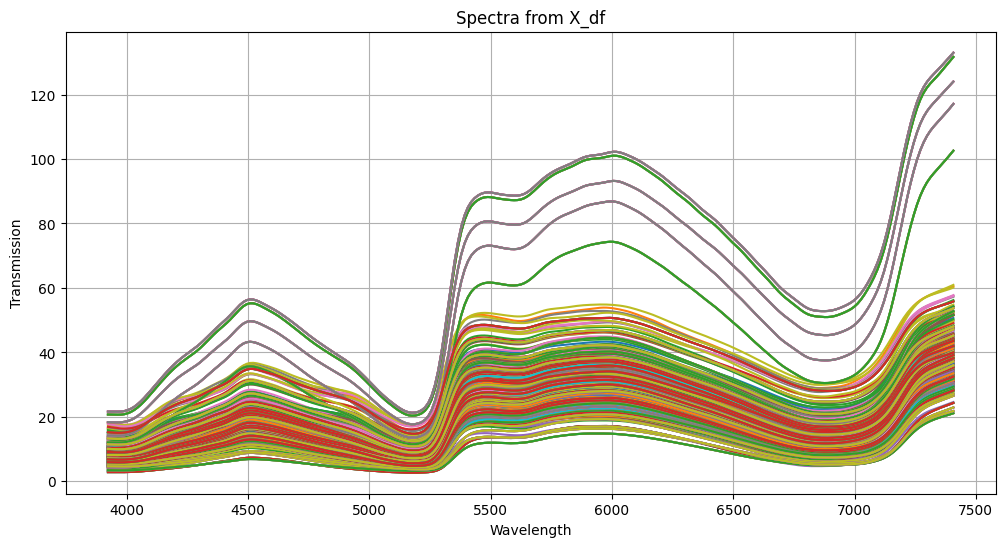

In [ ]:
plt.figure(figsize=(12, 6))
for index, row in X_df.iterrows():
    plt.plot(X_df.columns, row)

plt.title('Spectra from X_df')
plt.xlabel('Wavelength')
plt.ylabel('Transmission')
plt.grid(True)
plt.show()

In [19]:
# Preprocessing (T2A => Savitzky–Golay => SNV => mean)

from scipy.signal import savgol_filter
import numpy as np
import pandas as pd # Import pandas

def savitzky_golay(spectra_df, window_length, polyorder):
    #Apply Savitzky-Golay filter to the spectra.
    # Ensure window_length is odd and greater than polyorder
    if window_length % 2 == 0:
        window_length += 1
    if window_length <= polyorder:
        window_length = polyorder + 2
    # Apply filter row-wise and collect results
    filtered_data = spectra_df.apply(lambda x: savgol_filter(x, window_length, polyorder), axis=1)
    # Ensure the result is a DataFrame
    if isinstance(filtered_data, pd.Series):
        filtered_values = np.apply_along_axis(lambda row: savgol_filter(row, window_length, polyorder), axis=1, arr=spectra_df.values)
        return pd.DataFrame(filtered_values, index=spectra_df.index, columns=spectra_df.columns)
    else:
        return filtered_data # Should already be a DataFrame

def normalize_spectra(spectra_df):
    #Normalize each spectrum in the DataFrame by its L2 norm.
    return spectra_df.apply(lambda x: x / np.linalg.norm(x), axis=1)

def transmission_to_absorbance(spectra_df):
    # Add a small epsilon to avoid log10(0)
    epsilon = 1e-10
    return -np.log10(spectra_df + epsilon)

def snv(df, eps=1e-12):
    # ensure numeric (non-numeric -> NaN, which SNV will preserve)
    df = df.apply(pd.to_numeric, errors='coerce')

    row_mean = df.mean(axis=1)                  # Series indexed by rows
    row_std  = df.std(axis=1, ddof=0)           # population std; avoids NaN with 1 sample
    row_std  = row_std.mask(row_std < eps, 1.0) # avoid divide-by-zero

    # Row-wise center and scale (note axis=0!)
    return df.sub(row_mean, axis=0).div(row_std, axis=0)


def mean_center(spectra_df):
    #Perform mean centering on the spectral data.
    return spectra_df - spectra_df.mean(axis=0)

In [ ]:
# Apply preprocessing steps in the specified order
X_preprocessed = transmission_to_absorbance(X_df)
X_preprocessed = savitzky_golay(X_preprocessed, window_length=11, polyorder=2) # Example parameters
X_preprocessed = snv(X_preprocessed)
X_preprocessed = mean_center(X_preprocessed)

print("Preprocessing applied successfully.")
display(X_preprocessed.head())

Preprocessing applied successfully.


,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,4016.884537,4030.501097,4044.117648,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,-0.115557,-0.108332,-0.101090,-0.093831,-0.086555,-0.079262,-0.071231,-0.063137,-0.055965,-0.050327,...,-0.097146,-0.093684,-0.090694,-0.088366,-0.086934,-0.086190,-0.086181,-0.086906,-0.088367,-0.090563
Fermented_#_480927,0.097385,0.111757,0.123907,0.133834,0.141539,0.147021,0.152219,0.154392,0.152274,0.145475,...,-0.081890,-0.072916,-0.065943,-0.060950,-0.057883,-0.055358,-0.054240,-0.054528,-0.056223,-0.059325
Fermented_#_480929,-0.098122,-0.089083,-0.080477,-0.072304,-0.064564,-0.057257,-0.049068,-0.041613,-0.036040,-0.032914,...,-0.049802,-0.043932,-0.039028,-0.035202,-0.032497,-0.029991,-0.028214,-0.027166,-0.026848,-0.027259
Fermented_#_480932,-0.359644,-0.352048,-0.343123,-0.332868,-0.321283,-0.308369,-0.293148,-0.276562,-0.259741,-0.243338,...,-0.144054,-0.145237,-0.145983,-0.146897,-0.148447,-0.150681,-0.153334,-0.156406,-0.159896,-0.163806
Fermented_#_480933,-0.384668,-0.379514,-0.372661,-0.364110,-0.353859,-0.341910,-0.326848,-0.310192,-0.293299,-0.276960,...,-0.172006,-0.175434,-0.178237,-0.180921,-0.183962,-0.187708,-0.191719,-0.195994,-0.200533,-0.205337


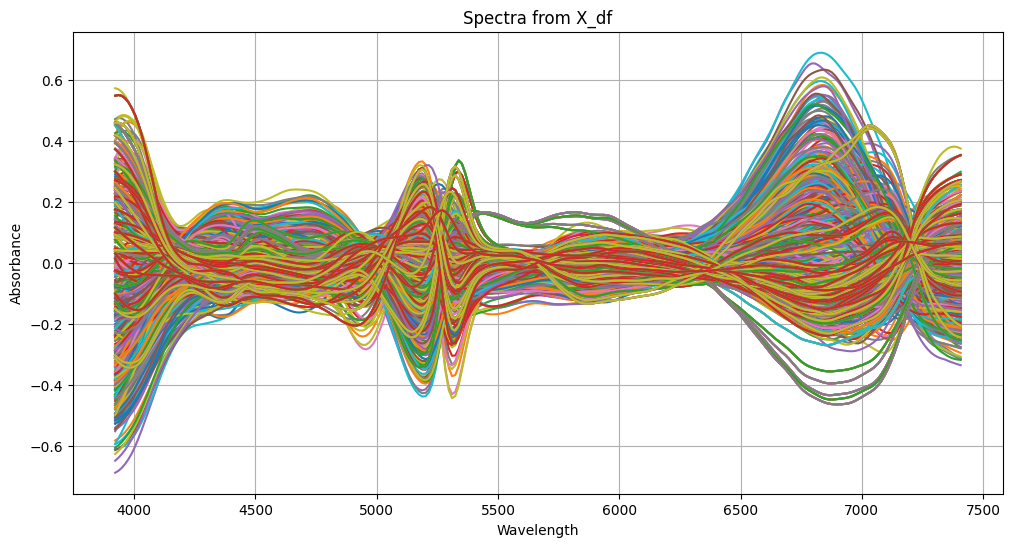

In [ ]:
plt.figure(figsize=(12, 6))
for index, row in X_preprocessed.iterrows():
    plt.plot(X_preprocessed.columns, row)

plt.title('Spectra from X_df')
plt.xlabel('Wavelength')
plt.ylabel('Absorbance')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y_df, test_size=0.3, random_state=42)

print("Data split into training and testing sets:")
print(f"Spectroscopic data (training): {X_train.shape}")
print(f"Spectroscopic data (testing): {X_test.shape}")
print(f"Moisture data (training): {y_train.shape}")
print(f"Moisture data (testing): {y_test.shape}")

Data split into training and testing sets:
Spectroscopic data (training): (548, 257)
Spectroscopic data (testing): (236, 257)
Moisture data (training): (548, 1)
Moisture data (testing): (236, 1)


# Task
Apply cross-validation with 5 folds to choose the number of Latent Variables (LVs) for a PLS model, testing from 1 to 20 LVs. Calculate and display the R2 score for each number of LVs and plot an elbow curve showing the R2 score for each LV.

Number of LVs: 1, Mean R2 Score: 0.1861
Number of LVs: 2, Mean R2 Score: 0.3941
Number of LVs: 3, Mean R2 Score: 0.5516
Number of LVs: 4, Mean R2 Score: 0.6349
Number of LVs: 5, Mean R2 Score: 0.7061
Number of LVs: 6, Mean R2 Score: 0.7541
Number of LVs: 7, Mean R2 Score: 0.7782
Number of LVs: 8, Mean R2 Score: 0.7913
Number of LVs: 9, Mean R2 Score: 0.8087
Number of LVs: 10, Mean R2 Score: 0.8114


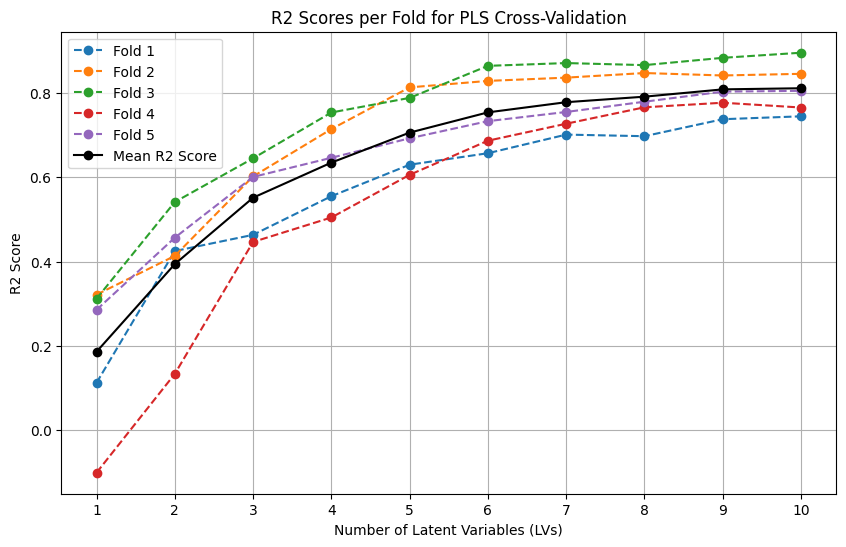


Optimal number of Latent Variables (based on highest Mean R2 score): 5


In [ ]:
# Before preprocessing
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the range of latent variables to test
n_components = np.arange(1, 11) # Testing from 1 to 20 LVs

r2_scores_all = [] # To store all R2 scores

# Perform cross-validation for each number of latent variables
for n in n_components:
    pls = PLSRegression(n_components=n)
    # Use cross_val_score with R2 as the scoring metric
    scores = cross_val_score(pls, X_train, y_train, cv=5, scoring='r2')
    r2_scores_all.append(scores) # Append the list of scores for each LV

# Display the R2 scores for each number of LVs
for n, scores in zip(n_components, r2_scores_all):
    #print(f"Number of LVs: {n}, R2 Scores (per fold): {scores}")
    print(f"Number of LVs: {n}, Mean R2 Score: {scores.mean():.4f}")


# Plot the individual R2 scores for each fold
plt.figure(figsize=(10, 6))
for i in range(5): # Assuming 5 folds
    plt.plot(n_components, [scores[i] for scores in r2_scores_all], marker='o', linestyle='--', label=f'Fold {i+1}')

# Plot the mean R2 scores
plt.plot(n_components, [scores.mean() for scores in r2_scores_all], marker='o', linestyle='-', color='black', label='Mean R2 Score')


plt.title('R2 Scores per Fold for PLS Cross-Validation')
plt.xlabel('Number of Latent Variables (LVs)')
plt.ylabel('R2 Score')
plt.xticks(n_components)
plt.legend()
plt.grid(True)
plt.show()

# Identify the optimal number of latent variables based on mean R2 score
mean_r2_scores = [scores.mean() for scores in r2_scores_all]
optimal_lv_index = np.argmax(mean_r2_scores)
optimal_lv = n_components[optimal_lv_index]
print(f"\nOptimal number of Latent Variables (based on highest Mean R2 score): 5")

Number of LVs: 1, Mean R2 Score: 0.5307
Number of LVs: 2, Mean R2 Score: 0.7361
Number of LVs: 3, Mean R2 Score: 0.7571
Number of LVs: 4, Mean R2 Score: 0.7843
Number of LVs: 5, Mean R2 Score: 0.8391
Number of LVs: 6, Mean R2 Score: 0.8450
Number of LVs: 7, Mean R2 Score: 0.8507
Number of LVs: 8, Mean R2 Score: 0.8538
Number of LVs: 9, Mean R2 Score: 0.8546
Number of LVs: 10, Mean R2 Score: 0.8559


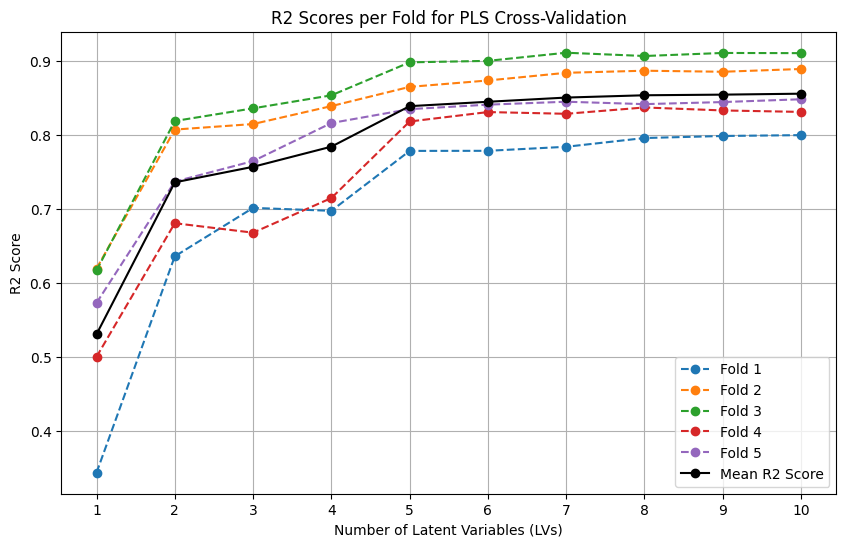


Optimal number of Latent Variables (based on highest Mean R2 score): 5


In [ ]:
# after preprocessing
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Define the range of latent variables to test
n_components = np.arange(1, 11) # Testing from 1 to 20 LVs

r2_scores_all = [] # To store all R2 scores

# Perform cross-validation for each number of latent variables
for n in n_components:
    pls = PLSRegression(n_components=n)
    # Use cross_val_score with R2 as the scoring metric
    scores = cross_val_score(pls, X_train, y_train, cv=5, scoring='r2')
    r2_scores_all.append(scores) # Append the list of scores for each LV

# Display the R2 scores for each number of LVs
for n, scores in zip(n_components, r2_scores_all):
    #print(f"Number of LVs: {n}, R2 Scores (per fold): {scores}")
    print(f"Number of LVs: {n}, Mean R2 Score: {scores.mean():.4f}")


# Plot the individual R2 scores for each fold
plt.figure(figsize=(10, 6))
for i in range(5): # Assuming 5 folds
    plt.plot(n_components, [scores[i] for scores in r2_scores_all], marker='o', linestyle='--', label=f'Fold {i+1}')

# Plot the mean R2 scores
plt.plot(n_components, [scores.mean() for scores in r2_scores_all], marker='o', linestyle='-', color='black', label='Mean R2 Score')


plt.title('R2 Scores per Fold for PLS Cross-Validation')
plt.xlabel('Number of Latent Variables (LVs)')
plt.ylabel('R2 Score')
plt.xticks(n_components)
plt.legend()
plt.grid(True)
plt.show()

# Identify the optimal number of latent variables based on mean R2 score
mean_r2_scores = [scores.mean() for scores in r2_scores_all]
optimal_lv_index = np.argmax(mean_r2_scores)
optimal_lv = n_components[optimal_lv_index]
print(f"\nOptimal number of Latent Variables (based on highest Mean R2 score): 5")

# R2 Score in CV with 5 Latent Variables:
## **0.8391**

In [ ]:
# Calculate RMSE for 5 LVs during cross-validation
pls_5_lv = PLSRegression(n_components=5)
rmse_scores = np.sqrt(-cross_val_score(pls_5_lv, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))

# Calculate the mean RMSE
mean_rmse_lv5 = np.mean(rmse_scores)

# Print the mean RMSE
print(f"\nMean RMSE in CV with 5 Latent Variables: {mean_rmse_lv5:.4f}")


Mean RMSE in CV with 5 Latent Variables: 2.4552


In [ ]:
# Instantiate a PLSRegression object with n_components=5
pls_model = PLSRegression(n_components=5)

# Fit the PLS model to the training data
pls_model.fit(X_train, y_train)

print("PLS model with 5 LVs trained successfully on the training data.")

PLS model with 5 LVs trained successfully on the training data.


In [ ]:
y_pred = pls_model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
# Calculate R2 score on the test set
r2 = r2_score(y_test, y_pred)

# Calculate Mean Squared Error (MSE) on the test set
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Print the calculated metrics
print(f"R2 Score on the test set: {r2:.4f}")
print(f"RMSE on the test set: {rmse:.4f}")

R2 Score on the test set: 0.8466
RMSE on the test set: 2.7401


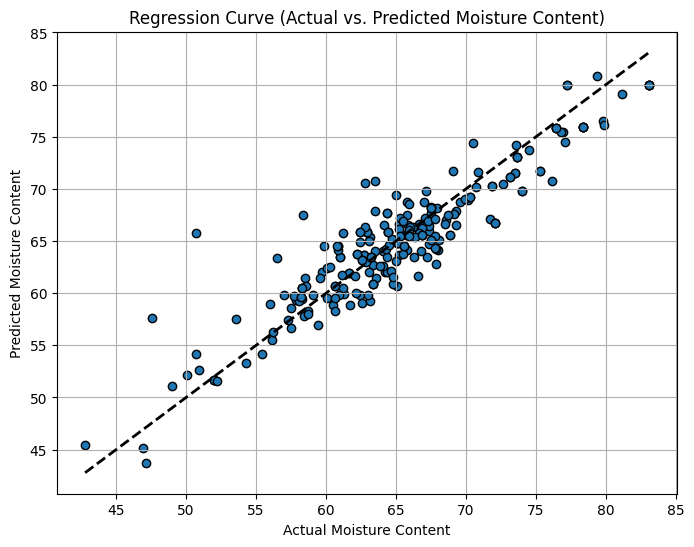

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, edgecolors=(0, 0, 0))
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Moisture Content')
plt.ylabel('Predicted Moisture Content')
plt.title('Regression Curve (Actual vs. Predicted Moisture Content)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.cross_decomposition import PLSRegression

# Instantiate PLS model with the optimal number of components (let's use 5 as you've focused on it)
# You can change n_components if you want to check CV for a different number of LVs
pls = PLSRegression(n_components=5)

# Perform 5-fold cross-validation and get R2 scores for each fold
r2_scores_folds = cross_val_score(pls, X_train, y_train, cv=5, scoring='r2')

# Print R2 score for each fold
print("R2 Scores for each fold in 5-fold cross-validation:")
for i, score in enumerate(r2_scores_folds):
    print(f"Fold {i+1}: {score:.4f}")

# Calculate and print the mean R2 score across folds
mean_r2_cv = r2_scores_folds.mean()
print(f"\nMean R2 Score across all folds: {mean_r2_cv:.4f}")

R2 Scores for each fold in 5-fold cross-validation:
Fold 1: 0.7786
Fold 2: 0.8651
Fold 3: 0.8983
Fold 4: 0.8184
Fold 5: 0.8351

Mean R2 Score across all folds: 0.8391


---
 - # **Now working with all predictors**
---

In [4]:
test_df = pd.read_csv('/content/drive/MyDrive/Si-Ware/moisture Si-Ware dataset/All predictors/DL_FreshCS_test_Multiple_Refs.csv')
display(test_df)
train_df = pd.read_csv('/content/drive/MyDrive/Si-Ware/moisture Si-Ware dataset/All predictors/DL_FreshCS_train_Multiple_Refs.csv')
display(train_df)

,Scanner,Sample,Moi,NDF,Starch,3921.568654,3935.18188,3948.795106,3962.408332,3976.021558,...,7284.03545,7297.648676,7311.261902,7324.875128,7338.488353,7352.101579,7365.714805,7379.328031,7392.941257,7406.554483
0,22030077,1,57.02,37.67,37.84,7.209724,7.202985,7.208119,7.222696,7.258278,...,38.932550,39.595226,40.219869,40.823632,41.396258,41.917661,42.375544,42.786740,43.177964,43.578847
1,22030077,1,57.02,37.67,37.84,6.802202,6.786788,6.780681,6.782455,6.805124,...,37.986222,38.679829,39.260441,39.754916,40.186044,40.582608,40.971723,41.394751,41.882680,42.451031
2,22030077,1,57.02,37.67,37.84,7.890556,7.886369,7.891463,7.899888,7.926916,...,40.293261,40.944037,41.545459,42.118273,42.643149,43.082208,43.410055,43.651383,43.865255,44.137235
3,22030077,1,57.02,37.67,37.84,7.741266,7.740978,7.762811,7.796629,7.849472,...,39.061605,39.623743,40.143299,40.666132,41.198445,41.715807,42.192246,42.641311,43.095348,43.595889
4,22030077,1,57.02,37.67,37.84,6.642168,6.647871,6.665882,6.686998,6.720952,...,37.307641,38.113560,38.788978,39.330331,39.747478,40.085455,40.398576,40.749179,41.170187,41.662778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,22030179,6,66.09,39.93,31.72,4.625264,4.590987,4.559324,4.538609,4.547827,...,30.146761,30.695254,31.218930,31.735490,32.235239,32.703073,33.132870,33.536604,33.946312,34.395520
428,22030179,6,66.09,39.93,31.72,4.697036,4.698089,4.681587,4.649535,4.628445,...,29.809300,30.504197,31.140799,31.725688,32.247351,32.694071,33.064726,33.377436,33.674737,34.008411
429,22030179,6,66.09,39.93,31.72,5.045485,5.036507,5.037608,5.043338,5.069877,...,31.416181,32.004128,32.502634,32.968987,33.436174,33.911647,34.378054,34.807339,35.182201,35.520784
430,22030179,6,66.09,39.93,31.72,4.726907,4.714416,4.715961,4.721099,4.738957,...,30.732153,31.369639,31.948807,32.515030,33.077851,33.622038,34.120100,34.551440,34.920691,35.266418


,Scanner ID,Sample ID,Moi,NDF,Starch,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
0,0,Fermented_#_519374,65.916589,34.34,37.86,7.942349,7.879306,7.818098,7.758485,7.708171,...,28.317286,28.983611,29.563827,30.078988,30.546206,30.978860,31.386878,31.777386,32.156782,32.532960
1,0,Fermented_#_519374,65.916589,34.34,37.86,7.419641,7.349567,7.286254,7.220075,7.152485,...,30.350159,31.063256,31.657065,32.168421,32.636662,33.087229,33.531162,33.970926,34.407003,34.843520
2,0,Fermented_#_519374,65.916589,34.34,37.86,7.505473,7.453863,7.412702,7.378596,7.353883,...,27.907187,28.491096,29.009951,29.480590,29.909929,30.302208,30.666498,31.019581,31.383385,31.778342
3,0,Fermented_#_519374,65.916589,34.34,37.86,7.501803,7.404250,7.300882,7.197936,7.111502,...,29.322861,29.997931,30.556176,31.034004,31.470861,31.893944,32.316505,32.741858,33.169309,33.600686
4,0,Fermented_#_519374,65.916589,34.34,37.86,7.249132,7.194527,7.142602,7.090535,7.044868,...,27.426496,28.029293,28.492752,28.871351,29.224750,29.601149,30.024162,30.489263,30.971840,31.443427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8158,22030101,Fresh_#_734007_5,61.020607,44.51,18.93,21.072748,21.082432,21.085079,21.039924,21.073130,...,126.318138,128.343010,130.100436,131.705051,133.224590,134.704392,136.130287,137.479463,138.765888,140.046953
8159,22030101,Fresh_#_734007_5,61.020607,44.51,18.93,23.158710,23.179768,23.193401,23.147826,23.190286,...,127.952107,129.934800,131.663848,133.222207,134.652865,136.001436,137.276250,138.491444,139.693804,140.950664
8160,22030101,Fresh_#_734007_5,61.020607,44.51,18.93,24.741724,24.778368,24.808218,24.767252,24.817121,...,127.661546,129.501327,131.093567,132.534489,133.872190,135.146467,136.349154,137.477328,138.571232,139.705585
8161,22030101,Fresh_#_734007_5,61.020607,44.51,18.93,23.022244,23.060517,23.097892,23.067785,23.122789,...,125.958720,127.809416,129.377359,130.814615,132.218385,133.645771,135.062750,136.410442,137.672160,138.892703


In [17]:
train_df_averaged = train_df.groupby('Sample ID').mean()
test_df_averaged = test_df

display(train_df_averaged)
display(test_df_averaged)

,Scanner ID,Moi,NDF,Starch,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,21060017.0,60.823286,35.56,37.20,7.729080,7.622415,7.546208,7.481664,7.423155,7.377601,...,34.616084,35.288379,35.845357,36.327769,36.777222,37.228529,37.695179,38.173677,38.652607,39.125314
Fermented_#_480927,21060017.0,50.485837,29.28,45.84,9.720940,9.584006,9.485654,9.401768,9.326291,9.270802,...,42.449703,43.100897,43.648566,44.136925,44.609373,45.097435,45.608556,46.131176,46.646221,47.142563
Fermented_#_480929,21060017.0,63.115711,41.44,33.25,7.551404,7.444440,7.367629,7.300275,7.237015,7.186719,...,34.907780,35.560699,36.103651,36.578961,37.026430,37.475247,37.932452,38.389652,38.834516,39.264430
Fermented_#_480932,21060017.0,65.419594,39.32,32.91,6.526686,6.434280,6.366056,6.301643,6.235700,6.175937,...,27.640183,28.252847,28.764077,29.212927,29.634762,30.056096,30.485576,30.919745,31.351121,31.777759
Fermented_#_480933,21060017.0,62.917114,31.35,41.55,6.840954,6.757292,6.697071,6.637614,6.573048,6.512227,...,28.069196,28.715024,29.254844,29.724470,30.160514,30.594707,31.040131,31.494608,31.948344,32.395361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fresh_#_738179_1,21100007.0,74.022226,53.74,16.56,5.950408,5.923261,5.899989,5.887302,5.890190,5.912077,...,28.549387,29.196989,29.731933,30.181309,30.574027,30.938049,31.296843,31.667972,32.062396,32.486178
Fresh_#_738179_2,21100007.0,74.022226,53.74,16.56,5.950408,5.923261,5.899989,5.887302,5.890190,5.912077,...,28.549387,29.196989,29.731933,30.181309,30.574027,30.938049,31.296843,31.667972,32.062396,32.486178
Fresh_#_738179_3,21100007.0,74.022226,53.74,16.56,5.950408,5.923261,5.899989,5.887302,5.890190,5.912077,...,28.549387,29.196989,29.731933,30.181309,30.574027,30.938049,31.296843,31.667972,32.062396,32.486178


,Scanner,Sample,Moi,NDF,Starch,3921.568654,3935.18188,3948.795106,3962.408332,3976.021558,...,7284.03545,7297.648676,7311.261902,7324.875128,7338.488353,7352.101579,7365.714805,7379.328031,7392.941257,7406.554483
0,22030077,1,57.02,37.67,37.84,7.209724,7.202985,7.208119,7.222696,7.258278,...,38.932550,39.595226,40.219869,40.823632,41.396258,41.917661,42.375544,42.786740,43.177964,43.578847
1,22030077,1,57.02,37.67,37.84,6.802202,6.786788,6.780681,6.782455,6.805124,...,37.986222,38.679829,39.260441,39.754916,40.186044,40.582608,40.971723,41.394751,41.882680,42.451031
2,22030077,1,57.02,37.67,37.84,7.890556,7.886369,7.891463,7.899888,7.926916,...,40.293261,40.944037,41.545459,42.118273,42.643149,43.082208,43.410055,43.651383,43.865255,44.137235
3,22030077,1,57.02,37.67,37.84,7.741266,7.740978,7.762811,7.796629,7.849472,...,39.061605,39.623743,40.143299,40.666132,41.198445,41.715807,42.192246,42.641311,43.095348,43.595889
4,22030077,1,57.02,37.67,37.84,6.642168,6.647871,6.665882,6.686998,6.720952,...,37.307641,38.113560,38.788978,39.330331,39.747478,40.085455,40.398576,40.749179,41.170187,41.662778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,22030179,6,66.09,39.93,31.72,4.625264,4.590987,4.559324,4.538609,4.547827,...,30.146761,30.695254,31.218930,31.735490,32.235239,32.703073,33.132870,33.536604,33.946312,34.395520
428,22030179,6,66.09,39.93,31.72,4.697036,4.698089,4.681587,4.649535,4.628445,...,29.809300,30.504197,31.140799,31.725688,32.247351,32.694071,33.064726,33.377436,33.674737,34.008411
429,22030179,6,66.09,39.93,31.72,5.045485,5.036507,5.037608,5.043338,5.069877,...,31.416181,32.004128,32.502634,32.968987,33.436174,33.911647,34.378054,34.807339,35.182201,35.520784
430,22030179,6,66.09,39.93,31.72,4.726907,4.714416,4.715961,4.721099,4.738957,...,30.732153,31.369639,31.948807,32.515030,33.077851,33.622038,34.120100,34.551440,34.920691,35.266418


In [18]:
target_cols = ['Moi', 'NDF', 'Starch']

# Identify spectral columns in train_df_averaged
spectral_cols_train = [col for col in train_df_averaged.columns if col not in target_cols and col != 'Scanner ID']

# Identify spectral columns in test_df_averaged - assuming the Scanner and Sample columns are not spectral and the rest are.
# I'll filter out 'Scanner' and 'Sample' explicitly and assume the remaining non-target columns are spectral.
non_spectral_non_target_cols_test = ['Scanner', 'Sample']
spectral_cols_test = [col for col in test_df_averaged.columns if col not in target_cols and col not in non_spectral_non_target_cols_test]


X_train = train_df_averaged[spectral_cols_train]
y_train = train_df_averaged[target_cols]

X_test = test_df_averaged[spectral_cols_test]
y_test = test_df_averaged[target_cols]

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (784, 257)
Shape of y_train: (784, 3)
Shape of X_test: (432, 257)
Shape of y_test: (432, 3)


In [20]:
# Apply preprocessing steps in the specified order
X_train_preprocessed = transmission_to_absorbance(X_train)
X_train_preprocessed = savitzky_golay(X_train_preprocessed, window_length=11, polyorder=2)
X_train_preprocessed = snv(X_train_preprocessed)
X_train_preprocessed = mean_center(X_train_preprocessed)

X_test_preprocessed = transmission_to_absorbance(X_test)
X_test_preprocessed = savitzky_golay(X_test_preprocessed, window_length=11, polyorder=2)
X_test_preprocessed = snv(X_test_preprocessed)
X_test_preprocessed = mean_center(X_test_preprocessed)

print("Preprocessing applied successfully to both training and testing sets.")
display(X_train_preprocessed.head())
display(X_test_preprocessed.head())

Preprocessing applied successfully to both training and testing sets.


,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,4016.884537,4030.501097,4044.117648,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,-0.115557,-0.108332,-0.101090,-0.093831,-0.086555,-0.079262,-0.071231,-0.063137,-0.055965,-0.050327,...,-0.097146,-0.093684,-0.090694,-0.088366,-0.086934,-0.086190,-0.086181,-0.086906,-0.088367,-0.090563
Fermented_#_480927,0.097385,0.111757,0.123907,0.133834,0.141539,0.147021,0.152219,0.154392,0.152274,0.145475,...,-0.081890,-0.072916,-0.065943,-0.060950,-0.057883,-0.055358,-0.054240,-0.054528,-0.056223,-0.059325
Fermented_#_480929,-0.098122,-0.089083,-0.080477,-0.072304,-0.064564,-0.057257,-0.049068,-0.041613,-0.036040,-0.032914,...,-0.049802,-0.043932,-0.039028,-0.035202,-0.032497,-0.029991,-0.028214,-0.027166,-0.026848,-0.027259
Fermented_#_480932,-0.359644,-0.352048,-0.343123,-0.332868,-0.321283,-0.308369,-0.293148,-0.276562,-0.259741,-0.243338,...,-0.144054,-0.145237,-0.145983,-0.146897,-0.148447,-0.150681,-0.153334,-0.156406,-0.159896,-0.163806
Fermented_#_480933,-0.384668,-0.379514,-0.372661,-0.364110,-0.353859,-0.341910,-0.326848,-0.310192,-0.293299,-0.276960,...,-0.172006,-0.175434,-0.178237,-0.180921,-0.183962,-0.187708,-0.191719,-0.195994,-0.200533,-0.205337


,3921.568654,3935.18188,3948.795106,3962.408332,3976.021558,3989.634784,4003.24801,4016.861236,4030.474462,4044.087688,...,7284.03545,7297.648676,7311.261902,7324.875128,7338.488353,7352.101579,7365.714805,7379.328031,7392.941257,7406.554483
0,0.012395,0.006918,0.002198,-0.001765,-0.004970,-0.007417,-0.009040,-0.009767,-0.009827,-0.009243,...,0.007766,0.006172,0.003332,-0.000072,-0.003319,-0.004976,-0.006175,-0.006916,-0.007200,-0.007025
1,-0.012419,-0.014597,-0.016152,-0.017083,-0.017391,-0.017077,-0.016153,-0.014506,-0.012224,-0.009176,...,-0.012305,-0.015066,-0.016126,-0.015377,-0.013390,-0.013474,-0.013579,-0.013705,-0.013854,-0.014023
2,0.072672,0.071345,0.069601,0.067440,0.064862,0.061866,0.059768,0.056528,0.051623,0.045326,...,0.035846,0.033620,0.031222,0.029481,0.029386,0.031810,0.035804,0.041368,0.048501,0.057204
3,0.083557,0.072772,0.063525,0.055817,0.049649,0.045019,0.042597,0.042224,0.042488,0.042101,...,0.028822,0.029117,0.028859,0.027711,0.025637,0.023110,0.019894,0.015989,0.011395,0.006112
4,0.006071,-0.002550,-0.009618,-0.015133,-0.019096,-0.021505,-0.021763,-0.020427,-0.018149,-0.015104,...,-0.030176,-0.038235,-0.043760,-0.045752,-0.044469,-0.044133,-0.042397,-0.039258,-0.034718,-0.028776


**Reasoning**:
The error indicates that the preprocessing functions were not defined in the current session. The previous code cell where they were defined was not executed again. I need to re-execute the cell with the function definitions before applying them.



In [9]:
from scipy.signal import savgol_filter
import numpy as np
import pandas as pd

def savitzky_golay(spectra_df, window_length, polyorder):
    #Apply Savitzky-Golay filter to the spectra.
    # Ensure window_length is odd and greater than polyorder
    if window_length % 2 == 0:
        window_length += 1
    if window_length <= polyorder:
        window_length = polyorder + 2
    # Apply filter row-wise and collect results
    filtered_data = spectra_df.apply(lambda x: savgol_filter(x, window_length, polyorder), axis=1)
    # Ensure the result is a DataFrame
    if isinstance(filtered_data, pd.Series):
        filtered_values = np.apply_along_axis(lambda row: savgol_filter(row, window_length, polyorder), axis=1, arr=spectra_df.values)
        return pd.DataFrame(filtered_values, index=spectra_df.index, columns=spectra_df.columns)
    else:
        return filtered_data # Should already be a DataFrame

def normalize_spectra(spectra_df):
    #Normalize each spectrum in the DataFrame by its L2 norm.
    return spectra_df.apply(lambda x: x / np.linalg.norm(x), axis=1)

def transmission_to_absorbance(spectra_df):
    # Add a small epsilon to avoid log10(0)
    epsilon = 1e-10
    return -np.log10(spectra_df + epsilon)

def snv(df, eps=1e-12):
    # ensure numeric (non-numeric -> NaN, which SNV will preserve)
    df = df.apply(pd.to_numeric, errors='coerce')

    row_mean = df.mean(axis=1)                  # Series indexed by rows
    row_std  = df.std(axis=1, ddof=0)           # population std; avoids NaN with 1 sample
    row_std  = row_std.mask(row_std < eps, 1.0) # avoid divide-by-zero

    # Row-wise center and scale (note axis=0!)
    return df.sub(row_mean, axis=0).div(row_std, axis=0)


def mean_center(spectra_df):
    #Perform mean centering on the spectral data.
    return spectra_df - spectra_df.mean(axis=0)

# Apply preprocessing steps in the specified order
X_train_preprocessed = transmission_to_absorbance(X_train)
X_train_preprocessed = savitzky_golay(X_train_preprocessed, window_length=11, polyorder=2)
X_train_preprocessed = snv(X_train_preprocessed)
X_train_preprocessed = mean_center(X_train_preprocessed)

X_test_preprocessed = transmission_to_absorbance(X_test)
X_test_preprocessed = savitzky_golay(X_test_preprocessed, window_length=11, polyorder=2)
X_test_preprocessed = snv(X_test_preprocessed)
X_test_preprocessed = mean_center(X_test_preprocessed)

print("Preprocessing applied successfully to both training and testing sets.")
display(X_train_preprocessed.head())
display(X_test_preprocessed.head())

Preprocessing applied successfully to both training and testing sets.


,3921.568654,3935.185205,3948.801765,3962.418316,3976.034876,3989.651427,4003.267987,4016.884537,4030.501097,4044.117648,...,7284.857826,7298.474386,7312.090937,7325.707497,7339.324048,7352.940608,7366.557159,7380.173719,7393.790269,7407.406829
Sample ID,,,,,,,,,,,,,,,,,,,,,
Fermented_#_480926,-0.115557,-0.108332,-0.101090,-0.093831,-0.086555,-0.079262,-0.071231,-0.063137,-0.055965,-0.050327,...,-0.097146,-0.093684,-0.090694,-0.088366,-0.086934,-0.086190,-0.086181,-0.086906,-0.088367,-0.090563
Fermented_#_480927,0.097385,0.111757,0.123907,0.133834,0.141539,0.147021,0.152219,0.154392,0.152274,0.145475,...,-0.081890,-0.072916,-0.065943,-0.060950,-0.057883,-0.055358,-0.054240,-0.054528,-0.056223,-0.059325
Fermented_#_480929,-0.098122,-0.089083,-0.080477,-0.072304,-0.064564,-0.057257,-0.049068,-0.041613,-0.036040,-0.032914,...,-0.049802,-0.043932,-0.039028,-0.035202,-0.032497,-0.029991,-0.028214,-0.027166,-0.026848,-0.027259
Fermented_#_480932,-0.359644,-0.352048,-0.343123,-0.332868,-0.321283,-0.308369,-0.293148,-0.276562,-0.259741,-0.243338,...,-0.144054,-0.145237,-0.145983,-0.146897,-0.148447,-0.150681,-0.153334,-0.156406,-0.159896,-0.163806
Fermented_#_480933,-0.384668,-0.379514,-0.372661,-0.364110,-0.353859,-0.341910,-0.326848,-0.310192,-0.293299,-0.276960,...,-0.172006,-0.175434,-0.178237,-0.180921,-0.183962,-0.187708,-0.191719,-0.195994,-0.200533,-0.205337


,3921.568654,3935.18188,3948.795106,3962.408332,3976.021558,3989.634784,4003.24801,4016.861236,4030.474462,4044.087688,...,7284.03545,7297.648676,7311.261902,7324.875128,7338.488353,7352.101579,7365.714805,7379.328031,7392.941257,7406.554483
Sample,,,,,,,,,,,,,,,,,,,,,
1,0.006138,0.004073,0.002407,0.001139,0.000271,-0.000199,0.000221,0.000880,0.001488,0.001939,...,-0.016362,-0.016934,-0.017476,-0.017912,-0.018181,-0.018281,-0.018249,-0.018084,-0.017786,-0.017356
2,0.025592,0.026885,0.027535,0.027542,0.026907,0.025629,0.023747,0.021096,0.017758,0.013896,...,0.009620,0.010521,0.011194,0.011719,0.012141,0.012491,0.012721,0.012828,0.012815,0.012680
3,0.126815,0.133269,0.137758,0.140283,0.140843,0.139439,0.136328,0.130873,0.123078,0.113151,...,0.042888,0.047161,0.050670,0.053551,0.056013,0.058527,0.060736,0.062640,0.064239,0.065533
4,0.113761,0.114564,0.114066,0.112269,0.109171,0.104773,0.099506,0.092450,0.083678,0.073558,...,0.075093,0.078616,0.081438,0.083459,0.084737,0.086170,0.087213,0.087867,0.088131,0.088006
5,-0.162677,-0.166580,-0.168406,-0.168155,-0.165826,-0.161420,-0.155606,-0.147051,-0.135700,-0.121947,...,-0.075851,-0.080931,-0.085038,-0.088286,-0.090869,-0.093575,-0.095858,-0.097718,-0.099154,-0.100167


In [21]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import numpy as np

# Create a dictionary to store CV results for each target
cv_results = {}

target_cols = ['Moi', 'NDF', 'Starch']
n_components_range = np.arange(1, 21) # Testing from 1 to 20 LVs

# Perform cross-validation for each target variable
for target in target_cols:
    print(f"Performing CV for target: {target}")
    r2_scores_target = []
    rmse_scores_target = []

    # Iterate through the number of latent variables
    for n in n_components_range:
        pls = PLSRegression(n_components=n)

        # Perform 5-fold cross-validation for R2
        r2_scores_folds = cross_val_score(pls, X_train_preprocessed, y_train[target], cv=5, scoring='r2')
        r2_scores_target.append(r2_scores_folds)

        # Perform 5-fold cross-validation for RMSE (using negative mean squared error)
        neg_mse_scores_folds = cross_val_score(pls, X_train_preprocessed, y_train[target], cv=5, scoring='neg_mean_squared_error')
        rmse_scores_folds = np.sqrt(-neg_mse_scores_folds)
        rmse_scores_target.append(rmse_scores_folds)

    # Store the results for the current target
    cv_results[target] = {'r2': r2_scores_target, 'rmse': rmse_scores_target}

print("Cross-validation completed for all targets.")

Performing CV for target: Moi
Performing CV for target: NDF
Performing CV for target: Starch
Cross-validation completed for all targets.


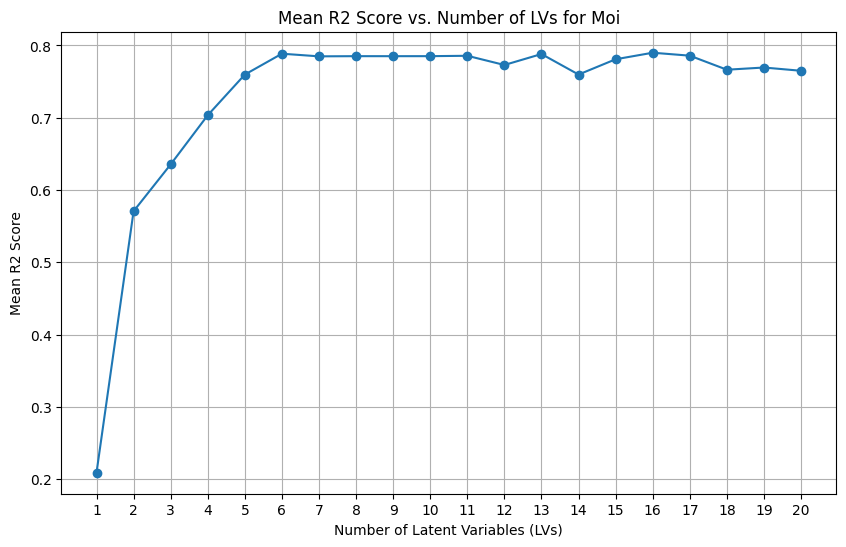

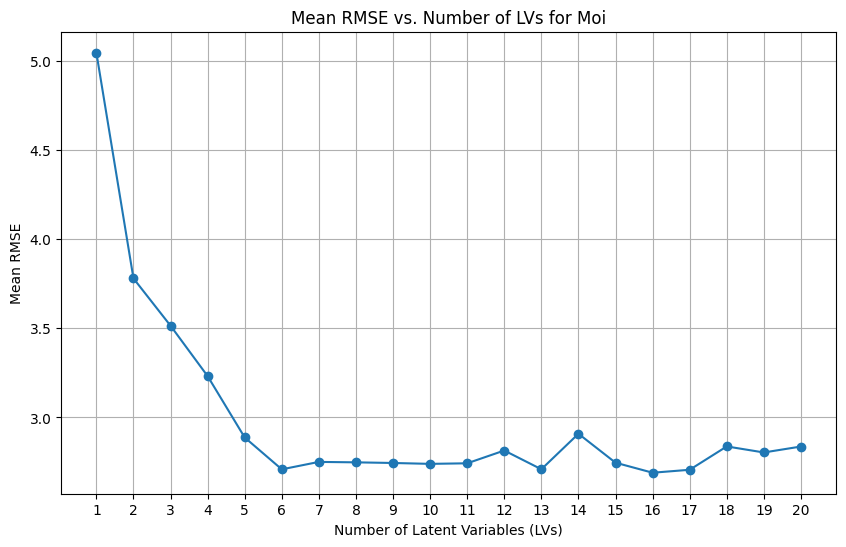

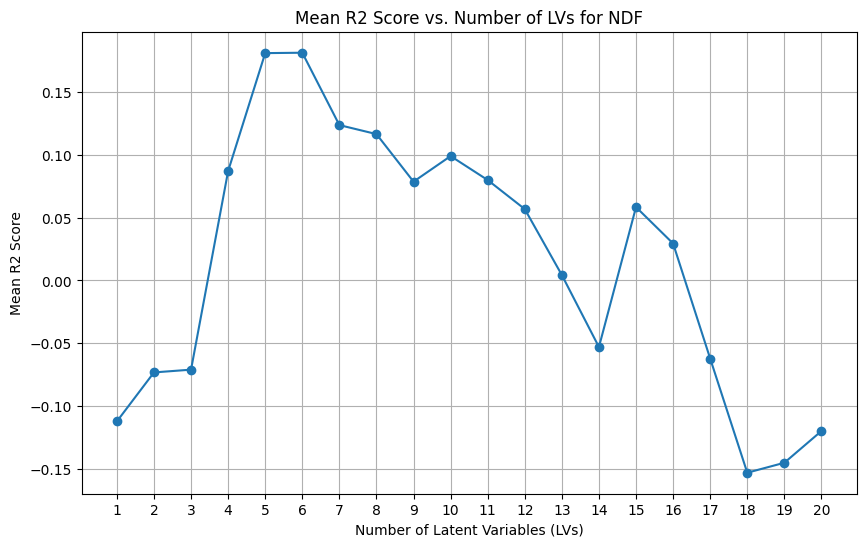

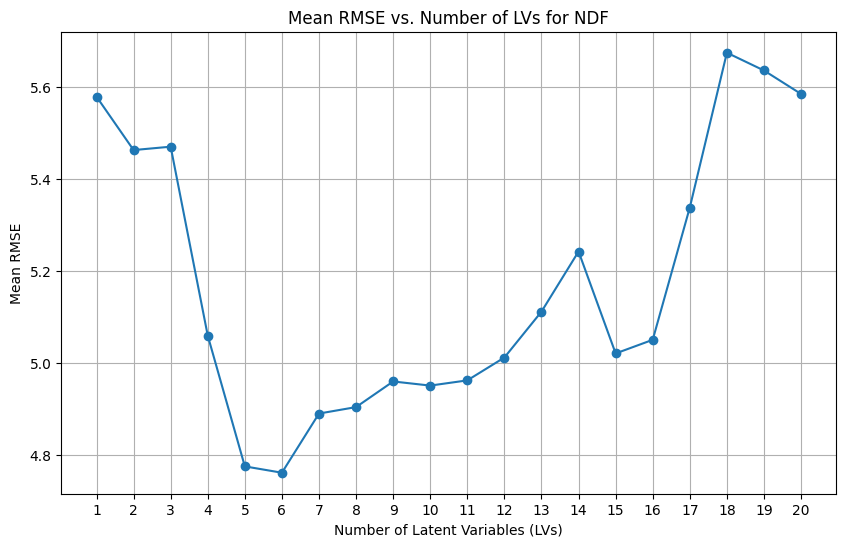

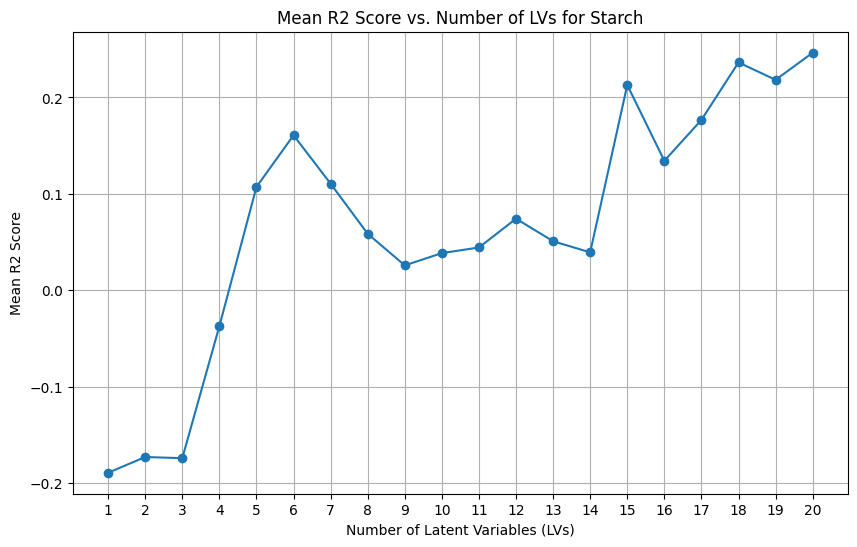

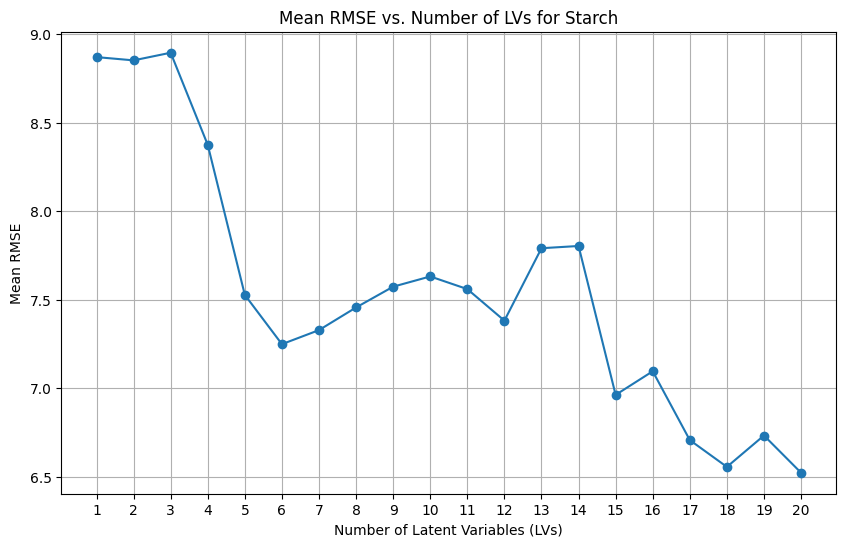

In [22]:
import matplotlib.pyplot as plt
import numpy as np

target_cols = ['Moi', 'NDF', 'Starch']
n_components_range = np.arange(1, 21)

# Plotting the CV results for each target
for target in target_cols:
    r2_scores_target = cv_results[target]['r2']
    rmse_scores_target = cv_results[target]['rmse']

    # Calculate mean R2 and RMSE across folds for each number of LVs
    mean_r2_scores = [np.mean(scores) for scores in r2_scores_target]
    mean_rmse_scores = [np.mean(scores) for scores in rmse_scores_target]

    # Plot R2 scores
    plt.figure(figsize=(10, 6))
    plt.plot(n_components_range, mean_r2_scores, marker='o', linestyle='-')
    plt.title(f'Mean R2 Score vs. Number of LVs for {target}')
    plt.xlabel('Number of Latent Variables (LVs)')
    plt.ylabel('Mean R2 Score')
    plt.xticks(n_components_range)
    plt.grid(True)
    plt.show()

    # Plot RMSE scores
    plt.figure(figsize=(10, 6))
    plt.plot(n_components_range, mean_rmse_scores, marker='o', linestyle='-')
    plt.title(f'Mean RMSE vs. Number of LVs for {target}')
    plt.xlabel('Number of Latent Variables (LVs)')
    plt.ylabel('Mean RMSE')
    plt.xticks(n_components_range)
    plt.grid(True)
    plt.show()

In [14]:
from sklearn.metrics import r2_score, mean_squared_error

# Create a dictionary to store the evaluation results
test_evaluation_results = {}

# Iterate through the target variables
for target in target_cols:
    print(f"\nEvaluating PLS model for target: {target}")

    # Get the optimal number of latent variables for the current target
    optimal_lv = optimal_lvs[target]
    print(f"Using optimal number of LVs: {optimal_lv}")

    # Instantiate a PLSRegression object with the optimal number of components
    pls_model = PLSRegression(n_components=optimal_lv)

    # Train the PLS model on the preprocessed training data
    pls_model.fit(X_train_preprocessed, y_train[target])
    print("Model trained successfully on the training data.")

    # Reindex X_test_preprocessed to match the columns of X_train_preprocessed
    X_test_preprocessed_reindexed = X_test_preprocessed.reindex(columns=X_train_preprocessed.columns, fill_value=0)

    # Make predictions on the reindexed preprocessed testing features
    y_pred_test = pls_model.predict(X_test_preprocessed_reindexed)
    print("Predictions made on the test set.")

    # Calculate R2 score on the test set
    r2_test = r2_score(y_test[target], y_pred_test)
    print(f"R2 Score on the test set: {r2_test:.4f}")

    # Calculate Mean Squared Error (MSE) on the test set
    mse_test = mean_squared_error(y_test[target], y_pred_test)

    # Calculate Root Mean Squared Error (RMSE)
    rmse_test = np.sqrt(mse_test)
    print(f"RMSE on the test set: {rmse_test:.4f}")

    # Store the evaluation results
    test_evaluation_results[target] = {'r2_test': r2_test, 'rmse_test': rmse_test}


Evaluating PLS model for target: Moi
Using optimal number of LVs: 16
Model trained successfully on the training data.
Predictions made on the test set.
R2 Score on the test set: -1.5595
RMSE on the test set: 8.9220

Evaluating PLS model for target: NDF
Using optimal number of LVs: 6
Model trained successfully on the training data.
Predictions made on the test set.
R2 Score on the test set: -1.6758
RMSE on the test set: 3.1630

Evaluating PLS model for target: Starch
Using optimal number of LVs: 20
Model trained successfully on the training data.
Predictions made on the test set.
R2 Score on the test set: -6.7835
RMSE on the test set: 10.7630



Plotting regression curve for target: Moi


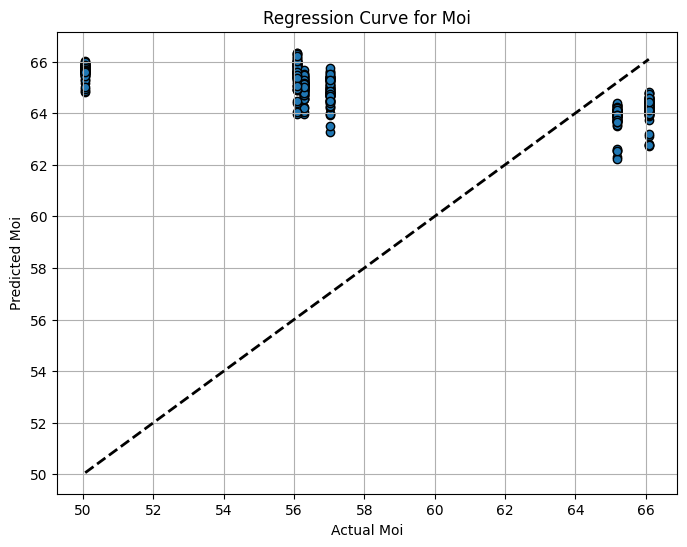


Plotting regression curve for target: NDF


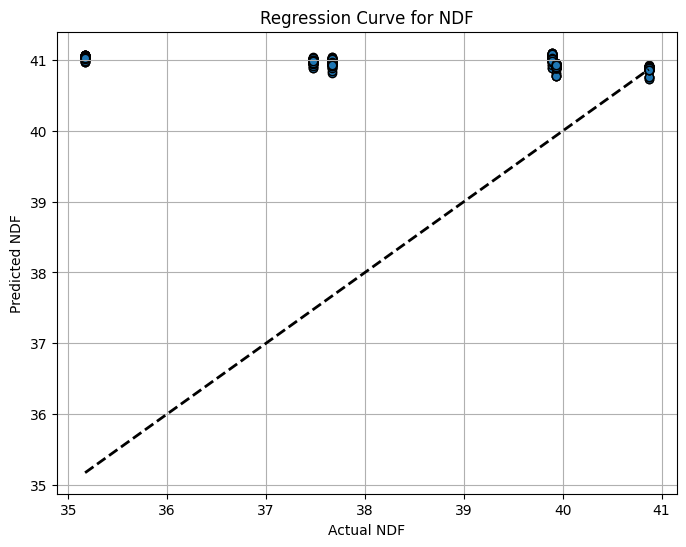


Plotting regression curve for target: Starch


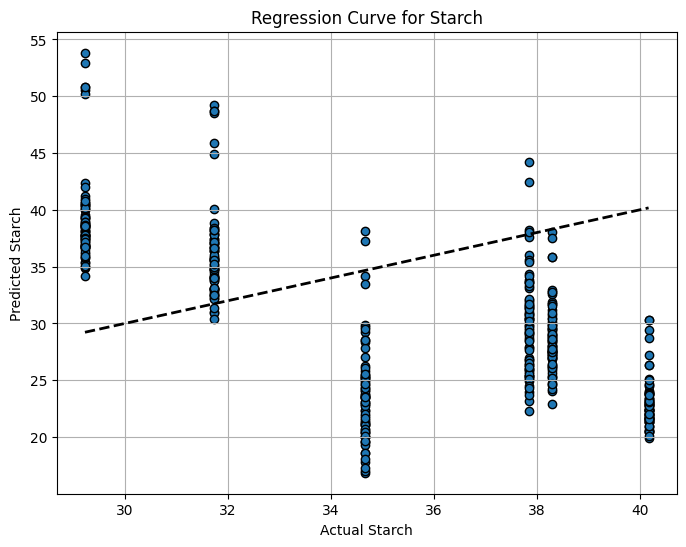

In [23]:
import matplotlib.pyplot as plt

target_cols = ['Moi', 'NDF', 'Starch']

# Iterate through each target variable
for target in target_cols:
    print(f"\nPlotting regression curve for target: {target}")

    # Access the actual test values
    y_test_actual = y_test[target]

    # Access the predicted test values (need to re-predict as y_pred_test was overwritten in the loop)
    # Get the optimal number of latent variables for the current target
    optimal_lv = optimal_lvs[target]

    # Instantiate a PLSRegression object with the optimal number of components
    pls_model = PLSRegression(n_components=optimal_lv)

    # Train the PLS model on the preprocessed training data
    pls_model.fit(X_train_preprocessed, y_train[target])

    # Reindex X_test_preprocessed to match the columns of X_train_preprocessed
    X_test_preprocessed_reindexed = X_test_preprocessed.reindex(columns=X_train_preprocessed.columns, fill_value=0)

    # Make predictions on the reindexed preprocessed testing features
    y_pred_test = pls_model.predict(X_test_preprocessed_reindexed)


    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_actual, y_pred_test, edgecolors=(0, 0, 0))

    # Add a diagonal line
    plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'k--', lw=2)

    # Add labels and title
    plt.xlabel(f'Actual {target}')
    plt.ylabel(f'Predicted {target}')
    plt.title(f'Regression Curve for {target}')

    # Add grid
    plt.grid(True)

    # Display the plot
    plt.show()
